# Práctica 1 - Módulo 2 Jimena López Robles

Realice un análisis exploratorio, tratamiento de datos, y entrene una Regresión Lineal para la variable de estatura (2.5 puntos), y una Regresión Logística para alguna variable categórica (de preferencia binaria) que proponga (2.5 puntos). Brinde interpretaciones de ambas a través de las betas o scores (2.5 puntos por cada una). Adicional realizar un Score Card del modelo de clasificación (+ 1 punto).

In [1]:

import numpy as np
import pandas as pd

# Data viz
from sklearn import set_config
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import CountVectorizer

# Model performance
from sklearn.metrics import roc_auc_score

# Modeling
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_selection import SelectKBest, f_classif, chi2,f_regression
from sklearn.preprocessing import StandardScaler,  MinMaxScaler

# Model performance
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

# Enviroment setup
set_config(display="diagram")
pd.set_option("display.max_columns", 50)
pd.set_option('display.float_format', lambda x: '%.8f' % x)

### Funciones auxiliares

In [2]:
def limpiar_a_numerico(df, columnas):
    """
    Extrae números de columnas de texto y las convierte a float.
    Si el valor no tiene números, pone NaN (Not a Number).
    """
    df_copy = df.copy()
    
    for col in columnas:

        df_copy[col] = df_copy[col].astype(str).str.extract(r'(\d+\.?\d*)')[0]       
        
    return df_copy

In [3]:
def corregir_estatura_a_metros(valor):
    """
    Convierte centímetros a metros si el valor es mayor a 3.
    Maneja nulos para evitar errores.
    """
    if pd.isna(valor):
        return valor
    
    # Si el valor es mayor a 10 (ej. 170), asumimos que son centímetros
    # Si es algo como 1.75, ya está en metros y lo dejamos igual
    if valor > 10:
        return valor / 100
    else:
        return valor


In [4]:
def freq_discrete(df, features):
    """
    Calcula y muestra tablas de frecuencias absolutas, relativas y acumuladas para variables categóricas.

    Parámetros
    ----------
    df : pandas.DataFrame
        DataFrame que contiene las variables a analizar.
    features : list of str
        Lista con los nombres de las columnas categóricas a analizar.

    Descripción
    -----------
    Para cada variable en `features`, imprime su nombre y muestra una tabla con:
      - Frecuencia absoluta de cada categoría.
      - Frecuencia relativa (porcentaje) de cada categoría.
      - Frecuencia absoluta acumulada.
      - Frecuencia relativa acumulada.
    Los valores se formatean para mejor visualización.

    Ejemplo
    -------
    freq_discrete(df, ["color", "country"])
    """
    for feature in features:
        print(f"Feature: {feature}")
        abs_series = df[feature].value_counts(dropna=False)
        rel_series = df[feature].value_counts(dropna=False, normalize=True)
        freq = pd.DataFrame({"Absolute frequency": abs_series, "Relative frequency": rel_series})
        freq["Accumulated frequency"] = freq["Absolute frequency"].cumsum()
        freq["Accumulated %"] = freq["Relative frequency"].cumsum()
        freq["Absolute frequency"] = freq["Absolute frequency"].map(lambda x: "{:,.0f}".format(x))
        freq["Relative frequency"] = freq["Relative frequency"].map(lambda x: "{:,.2%}".format(x))
        freq["Accumulated frequency"] = freq["Accumulated frequency"].map(lambda x: "{:,.0f}".format(x))
        freq["Accumulated %"] = freq["Accumulated %"].map(lambda x: "{:,.2%}".format(x))
        display(freq)

In [5]:
def WOE(df, var, tgt):
    aux = df[[var, tgt]].groupby(var).agg(["count", "sum"])
    aux["evento"] = aux[tgt, "sum"]
    aux["no_evento"] = aux[tgt, "count"] - aux[tgt, "sum"]
    aux["%evento"] = aux["evento"] / aux["evento"].sum()
    aux["%no_evento"] = aux["no_evento"] / aux["no_evento"].sum()
    aux["WOE"] = np.log(aux["%no_evento"] / aux["%evento"])
    display(aux)
    aux.columns = aux.columns.droplevel(1)
    aux = aux[["WOE"]].reset_index().rename(columns={"WOE": f"W_{var}"})
    df = df.merge(aux, on = var, how = "left")
    return df

In [6]:
def IV(df, var, tgt):
    aux = df[[var, tgt]].groupby(var).agg(["count", "sum"])
    aux["evento"] = aux[tgt, "sum"]
    aux["no_evento"] = aux[tgt, "count"] - aux[tgt, "sum"]
    aux["%evento"] = aux["evento"] / aux["evento"].sum()
    aux["%no_evento"] = aux["no_evento"] / aux["no_evento"].sum()
    aux["WOE"] = np.log(aux["%no_evento"] / aux["%evento"])
    aux["IV"] = (aux["%no_evento"] - aux["%evento"])*aux["WOE"]
    return aux["IV"].sum()

In [7]:
df=pd.read_csv("Team calor o team frío.csv")
df.sample(5)

,Marca temporal,Color primario favorito,Edad en años (numérica),Estatura en metros (numérica),Peso en kg (numérica),Tipo de personalidad,Número de vasos de agua que tomas al día (numérico),¿Día o noche?,Actividad física,Mascota favorita,¿Chile del que pica o del que no pica?,Número de hermanos (numérica),¿Las quesadillas van con queso?,Número de tatuajes (numérica),¿Team frío o team calor?
129,9/26/2024 18:52:49,azul,26,1.69,72,Introvertido,3,Dia,Si,perro,Del que pica,3,Con queso,0,Team frío
75,3/21/2024 17:20:19,Azul,22,1.76,85,Extrovertido,4,Día,Si,Gato,Del que pica,2,Con queso,3,Team frío
206,1/8/2026 18:49:46,Cian,22,1.79,90,Introvertido,6,Noche,Si,Gatos,Del que pica,1,Con queso,0,Team calor
199,1/8/2026 18:12:24,Verde,22,1.71,77,Extrovertido,4,Noche,Si,Perro,Del que pica,2,Sin queso,0,Team frío
5,3/16/2024 10:04:57,Amarillo,25,1.56,57,Extrovertido,15,Noche,Si,Gato,Del que pica,2,Con queso,2,NaN


### EDA

In [8]:
df.describe()

,Marca temporal,Color primario favorito,Edad en años (numérica),Estatura en metros (numérica),Peso en kg (numérica),Tipo de personalidad,Número de vasos de agua que tomas al día (numérico),¿Día o noche?,Actividad física,Mascota favorita,¿Chile del que pica o del que no pica?,Número de hermanos (numérica),¿Las quesadillas van con queso?,Número de tatuajes (numérica),¿Team frío o team calor?
count,207,207,207,207,195,207,207,207,207,206,207,207,207,207,193
unique,199,26,25,46,58,2,17,3,3,30,2,9,2,13,2
top,3/16/2024 10:04:42,Azul,24,1.7,63,Introvertido,8,Noche,Si,Perrro,Del que pica,2,Con queso,0,Team frío
freq,2,91,33,26,12,128,40,139,163,53,146,79,156,158,160


In [9]:
df.dtypes

Marca temporal                                         object
Color primario favorito                                object
Edad en años (numérica)                                object
Estatura en metros (numérica)                          object
Peso en kg (numérica)                                  object
Tipo de personalidad                                   object
Número de vasos de agua que tomas al día (numérico)    object
¿Día o noche?                                          object
Actividad física                                       object
Mascota favorita                                       object
¿Chile del que pica o del que no pica?                 object
Número de hermanos (numérica)                          object
¿Las quesadillas van con queso?                        object
Número de tatuajes (numérica)                          object
¿Team frío o team calor?                               object
dtype: object

In [10]:
# Haz una histograma dinámico de la variable estatura
fig = px.histogram(df.reset_index(), x="Estatura en metros (numérica)", nbins=40, title="Histogram of estatura")
fig.update_layout(xaxis_title="estatura", yaxis_title="Count")
fig.show()

#### Filtrado de variables

In [11]:
ls_cont = ["Peso en kg (numérica)"]
ls_disc = ["Edad en años (numérica)", "Número de vasos de agua que tomas al día (numérico)", "Número de hermanos (numérica)", "Número de tatuajes (numérica)"]
ls_cat = ["Color primario favorito", "Tipo de personalidad","¿Día o noche?","Actividad física", "Mascota favorita","¿Chile del que pica o del que no pica?", "¿Las quesadillas van con queso?", "¿Team frío o team calor?"]
ls_drop = []
ls_indx = ["Marca temporal"]
target = ["Estatura en metros (numérica)"]

#### Coerción de tipo de dato

In [12]:
df = df.set_index(ls_indx)

In [13]:
df.head()

,Color primario favorito,Edad en años (numérica),Estatura en metros (numérica),Peso en kg (numérica),Tipo de personalidad,Número de vasos de agua que tomas al día (numérico),¿Día o noche?,Actividad física,Mascota favorita,¿Chile del que pica o del que no pica?,Número de hermanos (numérica),¿Las quesadillas van con queso?,Número de tatuajes (numérica),¿Team frío o team calor?
Marca temporal,,,,,,,,,,,,,,
3/16/2024 10:04:42,Azul,29,1.92,107,Introvertido,6,Noche,¿Qué es eso?,Perrro,Del que pica,2,Con queso,0,NaN
3/16/2024 10:04:42,Azul,26,1.57,58,Introvertido,5,Noche,¿Qué es eso?,Perrro,Del que pica,0,Con queso,0,NaN
3/16/2024 10:04:49,Azul,25,1.71,78,Introvertido,3,Noche,Si,Perrro,Del que pica,1,Con queso,0,NaN
3/16/2024 10:04:51,Rojo,27,1.78,87,Introvertido,4,Noche,¿Qué es eso?,Perrro,Del que pica,1,Sin queso,0,NaN
3/16/2024 10:04:56,Azul,23,1.7,76,Introvertido,4,Noche,Si,Gato,Del que no pica,2,Con queso,0,NaN


In [14]:
df=limpiar_a_numerico(df, ls_cont)
df[ls_cont] = df[ls_cont].astype(float)

In [15]:
df=limpiar_a_numerico(df, target)
df[target] = df[target].astype(float)

In [16]:
df=limpiar_a_numerico(df, ls_disc)
df[ls_disc] = df[ls_disc].astype('Int64')

In [17]:
df.sample(5)

,Color primario favorito,Edad en años (numérica),Estatura en metros (numérica),Peso en kg (numérica),Tipo de personalidad,Número de vasos de agua que tomas al día (numérico),¿Día o noche?,Actividad física,Mascota favorita,¿Chile del que pica o del que no pica?,Número de hermanos (numérica),¿Las quesadillas van con queso?,Número de tatuajes (numérica),¿Team frío o team calor?
Marca temporal,,,,,,,,,,,,,,
1/8/2026 18:11:20,Rojo,31,1.80000000,103.00000000,Extrovertido,10,Dia,Si,Perro,Del que pica,2,Con queso,2,Team frío
6/6/2024 19:30:59,oro rosa,27,1.73000000,80.00000000,Extrovertido,12,Dia,Si,Perro,Del que pica,1,Sin queso,1,Team calor
26/6/2025 18:09:08,Azul,23,1.63000000,60.00000000,Introvertido,8,Dia,Si,Perros,Del que pica,2,Sin queso,4,Team frío
26/6/2025 18:11:59,Verde,24,1.70000000,68.00000000,Introvertido,5,Noche,Si,Canino,Del que no pica,1,Con queso,0,Team frío
1/8/2026 18:11:15,azul,25,166.00000000,62.00000000,Introvertido,12,Dia,Si,piedra,Del que pica,2,Con queso,0,Team frío


In [18]:
df[ls_cat] = df[ls_cat].fillna("").astype(str)

#### EDA continuas

In [19]:
for col in ls_cont:
    fig = px.histogram(df.reset_index(), x=col, title=col)
    fig.show()

#### EDA discretas

In [20]:
for col in ls_disc:
    fig = px.histogram(df.reset_index(), x=col, title=col)
    fig.show()

#### EDA target

In [21]:
fig = px.histogram(df.reset_index(), x="Estatura en metros (numérica)", title="Estatura en metros (numérica)")
fig.show()

In [22]:
df['Estatura en metros (numérica)'] = df['Estatura en metros (numérica)'].apply(corregir_estatura_a_metros)

In [23]:
fig = px.histogram(df.reset_index(), x="Estatura en metros (numérica)", nbins=40, title="Histogram of estatura")
fig.update_layout(xaxis_title="estatura", yaxis_title="Count")
fig.show()

#### EDA categoricas

In [24]:
for col in ls_cat:
    fig = px.histogram(df.reset_index(), x=col, title=col)
    fig.show()

### Feature Engineering

In [25]:
# Diccionario binario correcto (una columna por variable)
mapa_binario = {
    "¿Día o noche?": {
        "variantes_1": ["Dia", "Día"],
        "variantes_0": ["Noche"],
        "nombre_col": "dia"
    },
    "¿Chile del que pica o del que no pica?": {
        "variantes_1": ["Del que pica"],
        "variantes_0": ["Del que no pica"],
        "nombre_col": "chile_pica"
    },
    "¿Las quesadillas van con queso?": {
        "variantes_1": ["Con queso"],
        "variantes_0": ["Sin queso"],
        "nombre_col": "quesadilla_queso"
    },
    "¿Team frío o team calor?": {
        "variantes_1": ["Team frío"],
        "variantes_0": ["Team calor"],
        "nombre_col": "team_frio"
    },
    "Actividad física": {
        "variantes_1": ["Si"],
        "variantes_0": ["No"],
        "nombre_col": "actividad_fisica"
    },
    "Tipo de personalidad": {
        "variantes_1": ["Introvertido"],
        "variantes_0": ["Extrovertido"],
        "nombre_col": "introvertido"
    }
}
df_binario = pd.DataFrame(index=df.index)

for col, cfg in mapa_binario.items():
    if col in df.columns:
        df_binario[cfg["nombre_col"]] = df[col].isin(cfg["variantes_1"]).astype(int)

print(df_binario.columns.tolist())


['dia', 'chile_pica', 'quesadilla_queso', 'team_frio', 'actividad_fisica', 'introvertido']


In [26]:
df_binario.sample(5)

,dia,chile_pica,quesadilla_queso,team_frio,actividad_fisica,introvertido
Marca temporal,,,,,,
3/21/2024 16:09:33,1,1,0,1,1,1
3/21/2024 18:32:10,0,1,0,0,0,1
26/6/2025 18:09:49,0,1,1,1,0,1
3/21/2024 16:08:39,0,0,1,1,0,1
26/6/2025 18:10:41,1,1,1,1,1,1


#### Color primario favorito

In [27]:
# Convertir a minúsculas y quitar espacios extra
df['Color_Limpio'] = df['Color primario favorito'].str.lower().str.strip()

# Agrupar variantes manuales 
correcciones = {
    "azul cielo": "azul",
    "azul marino": "azul",
    "oro rosa": "rosa",
    "mostaza": "amarillo",
    "granate": "rojo"
}
df['Color_Limpio'] = df['Color_Limpio'].replace(correcciones)
df.head()

,Color primario favorito,Edad en años (numérica),Estatura en metros (numérica),Peso en kg (numérica),Tipo de personalidad,Número de vasos de agua que tomas al día (numérico),¿Día o noche?,Actividad física,Mascota favorita,¿Chile del que pica o del que no pica?,Número de hermanos (numérica),¿Las quesadillas van con queso?,Número de tatuajes (numérica),¿Team frío o team calor?,Color_Limpio
Marca temporal,,,,,,,,,,,,,,,
3/16/2024 10:04:42,Azul,29,1.92000000,107.00000000,Introvertido,6,Noche,¿Qué es eso?,Perrro,Del que pica,2,Con queso,0,,azul
3/16/2024 10:04:42,Azul,26,1.57000000,58.00000000,Introvertido,5,Noche,¿Qué es eso?,Perrro,Del que pica,0,Con queso,0,,azul
3/16/2024 10:04:49,Azul,25,1.71000000,78.00000000,Introvertido,3,Noche,Si,Perrro,Del que pica,1,Con queso,0,,azul
3/16/2024 10:04:51,Rojo,27,1.78000000,87.00000000,Introvertido,4,Noche,¿Qué es eso?,Perrro,Del que pica,1,Sin queso,0,,rojo
3/16/2024 10:04:56,Azul,23,1.70000000,76.00000000,Introvertido,4,Noche,Si,Gato,Del que no pica,2,Con queso,0,,azul


In [28]:
fig = px.histogram(df.reset_index(), x="Color_Limpio", title="Color_limpio")
fig.show()

In [29]:
# Definimos un umbral (ej. colores con menos de 5 menciones)
frecuencias = df['Color_Limpio'].value_counts()
colores_bajos = frecuencias[frecuencias < 5].index

df['Color_Agrupado'] = df['Color_Limpio'].replace(colores_bajos, 'otros')

In [30]:
fig = px.histogram(df.reset_index(), x="Color_Agrupado", title="Color_Agrupado")
fig.show()

In [31]:
#El negro lo vamos a mover a otros
df.loc[df['Color_Agrupado'] == 'negro', 'Color_Agrupado'] = 'otros'

In [32]:
fig = px.histogram(df.reset_index(), x="Color_Agrupado", title="Color_Agrupado")
fig.show()

In [33]:
# Usamos binary=True para que solo ponga 1 (es) o 0 (no es)
vect = CountVectorizer(binary=True)

col_colores = df["Color_Agrupado"]
X = vect.fit_transform(col_colores)

#Armamos el DataFrame binario con tu lógica
df_colores_bin = pd.DataFrame(
    data=X.todense(), 
    columns=[f"color_primario_favorito_{x}" for x in vect.get_feature_names_out()],
    index=df.index
)
df_colores_bin.sample(5)

,color_primario_favorito_amarillo,color_primario_favorito_azul,color_primario_favorito_otros,color_primario_favorito_rojo,color_primario_favorito_verde
Marca temporal,,,,,
1/8/2026 18:12:41,0,0,0,1,0
9/26/2024 18:50:53,0,1,0,0,0
6/6/2024 19:30:25,0,0,1,0,0
3/16/2024 10:04:56,0,1,0,0,0
3/21/2024 17:16:23,0,1,0,0,0


In [34]:
df.drop(columns=["Color_Agrupado", "Color_Limpio"], inplace=True)

#### Mascota favorita

In [35]:
df['Mascota_Limpia'] = df['Mascota favorita'].str.lower().str.strip()

mapa_mascotas = {
    # Familia Canina
    "perrro": "perro", "perro": "perro", "perros": "perro", "perritos": "perro", 
    "canino": "perro",

    # Familia Felina
    "gato": "gato", "gatos": "gato", "michi": "gato", "cats": "gato"
    
}

df['Mascota_Agrupada'] = df['Mascota_Limpia'].replace(mapa_mascotas)
df.sample(5)


,Color primario favorito,Edad en años (numérica),Estatura en metros (numérica),Peso en kg (numérica),Tipo de personalidad,Número de vasos de agua que tomas al día (numérico),¿Día o noche?,Actividad física,Mascota favorita,¿Chile del que pica o del que no pica?,Número de hermanos (numérica),¿Las quesadillas van con queso?,Número de tatuajes (numérica),¿Team frío o team calor?,Mascota_Limpia,Mascota_Agrupada
Marca temporal,,,,,,,,,,,,,,,,
9/26/2024 19:37:31,azul,22,1.84000000,68.00000000,Introvertido,6,Noche,Si,perro,Del que no pica,1,Con queso,0,Team frío,perro,perro
1/8/2026 18:09:07,Azul,29,1.74000000,82.00000000,Introvertido,8,Noche,No,Perro,Del que pica,1,Con queso,0,Team frío,perro,perro
9/26/2024 18:52:38,azul,23,1.58000000,52.00000000,Extrovertido,10,Noche,Si,perritos,Del que no pica,1,Con queso,0,Team frío,perritos,perro
1/8/2026 18:11:15,azul,25,1.66000000,62.00000000,Introvertido,12,Dia,Si,piedra,Del que pica,2,Con queso,0,Team frío,piedra,piedra
3/21/2024 16:58:14,Azul,21,1.56000000,57.00000000,Extrovertido,7,Noche,Si,Gato,Del que pica,2,Con queso,0,Team frío,gato,gato


In [36]:
fig = px.histogram(df.reset_index(), x="Mascota_Agrupada", title="Mascota_Agrupada")
fig.show()

In [37]:
#Todo lo que no sea perro o gato, va a "otros"
opciones_principales = ['perro', 'gato']
df.loc[~df['Mascota_Agrupada'].isin(opciones_principales), 'Mascota_Agrupada'] = 'otros'
fig = px.histogram(df.reset_index(), x="Mascota_Agrupada", title="Mascota_Agrupada")
fig.show()

In [38]:
# Usamos el vectorizador para generar las columnas binarias
vect_mascota = CountVectorizer(binary=True, token_pattern=r"(?u)\b\w+\b")

# Aseguramos que no haya nulos
col_mascota = df["Mascota_Agrupada"]

X_mascota = vect_mascota.fit_transform(col_mascota)

# Creamos el DataFrame independiente
df_mascota_bin = pd.DataFrame(
    data=X_mascota.todense(), 
    columns=[f"mascota_favorita_{x}" for x in vect_mascota.get_feature_names_out()],
    index=df.index
)
df_mascota_bin.sample(5)

,mascota_favorita_gato,mascota_favorita_otros,mascota_favorita_perro
Marca temporal,,,
3/16/2024 10:07:07,0,0,1
1/8/2026 18:10:07,0,0,1
6/6/2024 19:41:50,0,0,1
9/26/2024 18:53:12,0,0,1
1/8/2026 18:09:07,0,0,1


In [39]:
df.drop(columns=["Mascota_Agrupada", "Mascota_Limpia"], inplace=True)

In [40]:
#Unimos las columnas binarias al data farme original
df = pd.concat([df, df_binario, df_colores_bin, df_mascota_bin], axis=1)

In [41]:
freq_discrete(df, ls_cat)

Feature: Color primario favorito


,Absolute frequency,Relative frequency,Accumulated frequency,Accumulated %
Color primario favorito,,,,
Azul,91,43.96%,91,43.96%
Rojo,42,20.29%,133,64.25%
azul,19,9.18%,152,73.43%
Verde,13,6.28%,165,79.71%
Amarillo,12,5.80%,177,85.51%
negro,4,1.93%,181,87.44%
rojo,3,1.45%,184,88.89%
Morado,3,1.45%,187,90.34%
Negro,2,0.97%,189,91.30%


Feature: Tipo de personalidad


,Absolute frequency,Relative frequency,Accumulated frequency,Accumulated %
Tipo de personalidad,,,,
Introvertido,128,61.84%,128,61.84%
Extrovertido,79,38.16%,207,100.00%


Feature: ¿Día o noche?


,Absolute frequency,Relative frequency,Accumulated frequency,Accumulated %
¿Día o noche?,,,,
Noche,139,67.15%,139,67.15%
Dia,51,24.64%,190,91.79%
Día,17,8.21%,207,100.00%


Feature: Actividad física


,Absolute frequency,Relative frequency,Accumulated frequency,Accumulated %
Actividad física,,,,
Si,163,78.74%,163,78.74%
¿Qué es eso?,34,16.43%,197,95.17%
No,10,4.83%,207,100.00%


Feature: Mascota favorita


,Absolute frequency,Relative frequency,Accumulated frequency,Accumulated %
Mascota favorita,,,,
Perrro,53,25.60%,53,25.60%
Perro,50,24.15%,103,49.76%
Gato,46,22.22%,149,71.98%
perro,14,6.76%,163,78.74%
Perros,9,4.35%,172,83.09%
Otros,4,1.93%,176,85.02%
gatos,3,1.45%,179,86.47%
perros,3,1.45%,182,87.92%
Gatos,3,1.45%,185,89.37%


Feature: ¿Chile del que pica o del que no pica?


,Absolute frequency,Relative frequency,Accumulated frequency,Accumulated %
¿Chile del que pica o del que no pica?,,,,
Del que pica,146,70.53%,146,70.53%
Del que no pica,61,29.47%,207,100.00%


Feature: ¿Las quesadillas van con queso?


,Absolute frequency,Relative frequency,Accumulated frequency,Accumulated %
¿Las quesadillas van con queso?,,,,
Con queso,156,75.36%,156,75.36%
Sin queso,51,24.64%,207,100.00%


Feature: ¿Team frío o team calor?


,Absolute frequency,Relative frequency,Accumulated frequency,Accumulated %
¿Team frío o team calor?,,,,
Team frío,160,77.29%,160,77.29%
Team calor,33,15.94%,193,93.24%
,14,6.76%,207,100.00%


In [42]:
#Quitamos las columnas categoricas
df.drop(columns=ls_cat, inplace=True)

In [43]:
df.sample(10)

,Edad en años (numérica),Estatura en metros (numérica),Peso en kg (numérica),Número de vasos de agua que tomas al día (numérico),Número de hermanos (numérica),Número de tatuajes (numérica),dia,chile_pica,quesadilla_queso,team_frio,actividad_fisica,introvertido,color_primario_favorito_amarillo,color_primario_favorito_azul,color_primario_favorito_otros,color_primario_favorito_rojo,color_primario_favorito_verde,mascota_favorita_gato,mascota_favorita_otros,mascota_favorita_perro
Marca temporal,,,,,,,,,,,,,,,,,,,,
6/6/2024 19:37:48,41,1.88000000,101.00000000,6,1,0,0,1,1,1,1,0,0,1,0,0,0,0,0,1
1/8/2026 18:10:07,30,1.78000000,64.00000000,8,2,0,1,1,0,0,0,1,0,0,0,0,1,0,0,1
3/16/2024 10:09:00,25,1.79000000,89.00000000,6,1,1,0,1,1,1,1,1,0,1,0,0,0,0,0,1
3/16/2024 10:04:51,27,1.78000000,87.00000000,4,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1
1/8/2026 18:08:45,27,1.83000000,102.00000000,8,0,0,0,0,1,1,1,0,0,0,0,0,1,0,0,1
6/6/2024 19:33:40,28,1.63000000,NaN,8,2,0,0,1,0,1,1,1,0,0,1,0,0,0,0,1
6/6/2024 20:01:55,36,1.70000000,76.00000000,9,2,0,0,1,1,1,0,1,0,0,0,0,1,0,1,0
1/8/2026 18:11:52,25,1.70000000,68.00000000,5,0,0,1,0,1,1,1,0,1,0,0,0,0,0,0,1
6/6/2024 19:30:25,22,1.63000000,67.00000000,4,2,0,0,0,1,0,1,0,0,0,1,0,0,0,0,1


### DATA CLEANING 

### DETECCIÓN Y REMOCIÓN DE VALORES EXTREMOS (OUTLIERS)

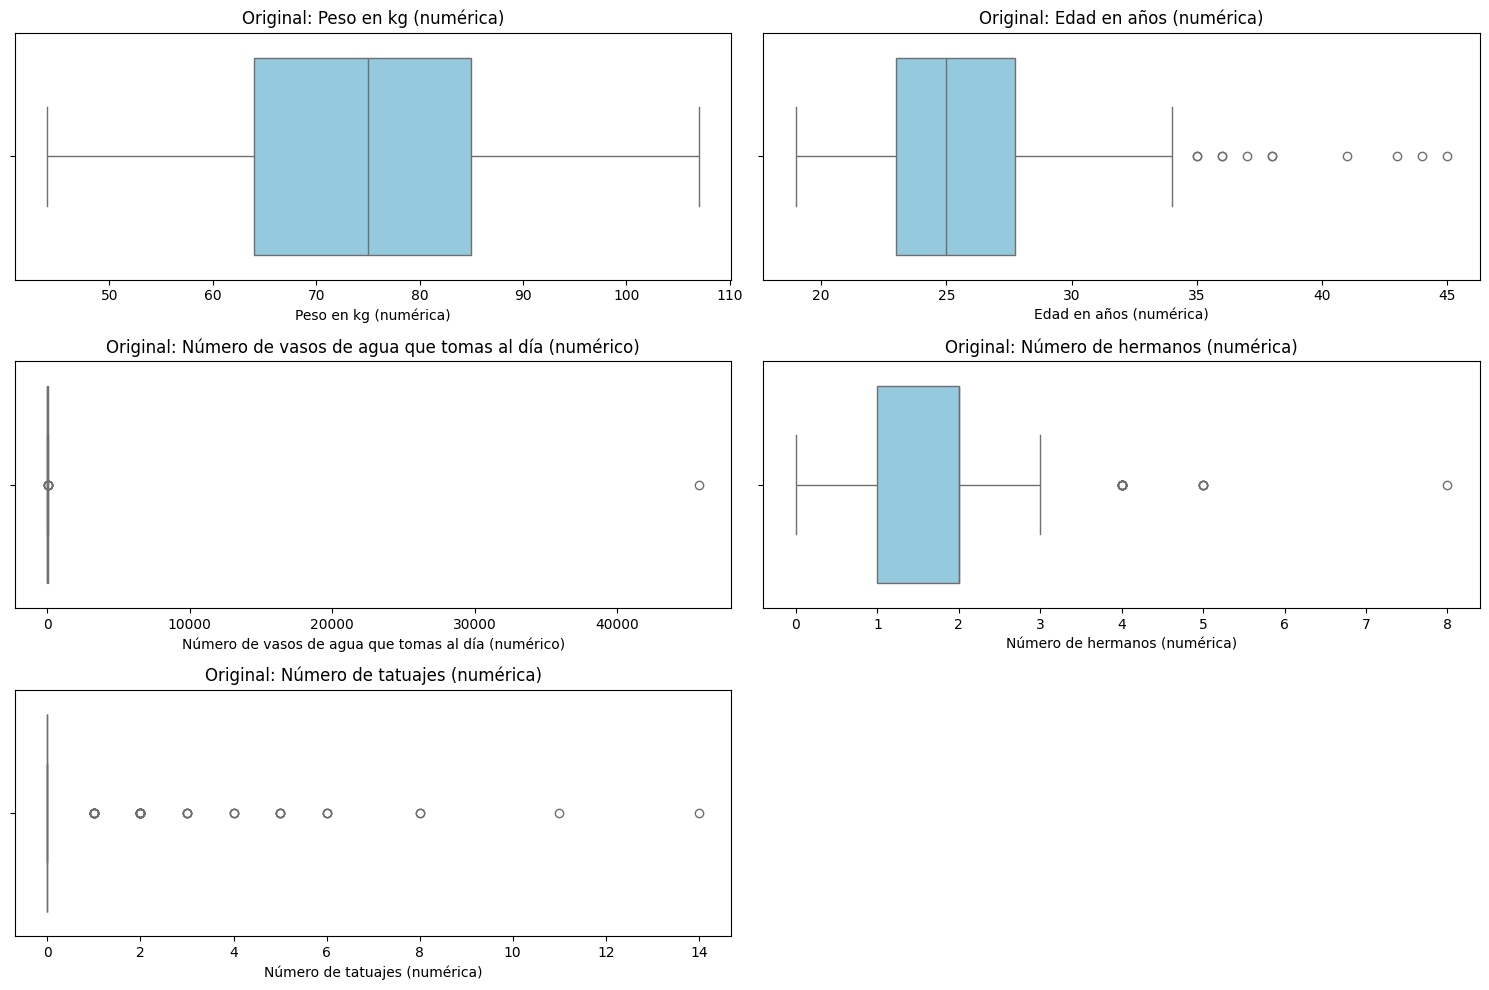

Conteo de Outliers por columna:
Número de tatuajes (numérica)                          46
Número de hermanos (numérica)                          16
Edad en años (numérica)                                11
Número de vasos de agua que tomas al día (numérico)     7
Peso en kg (numérica)                                   0
dtype: int64


In [44]:
numeric_cols = ls_cont + ls_disc 
numeric_cols
# Convertimos a float para que acepten los límites decimales del IQR
for col in numeric_cols:
    df[col] = df[col].astype('float64')

# Configuración de los cálculos IQR
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

df = df.reset_index(drop=True)

# Visualización ANTES de la limpieza
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(len(numeric_cols) // 2 + 1, 2, i + 1)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Original: {col}')

plt.tight_layout()
plt.show()

# Mostrar el conteo de outliers 
outliers_mask = (df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))
print("Conteo de Outliers por columna:")
print(outliers_mask.sum().sort_values(ascending=False))


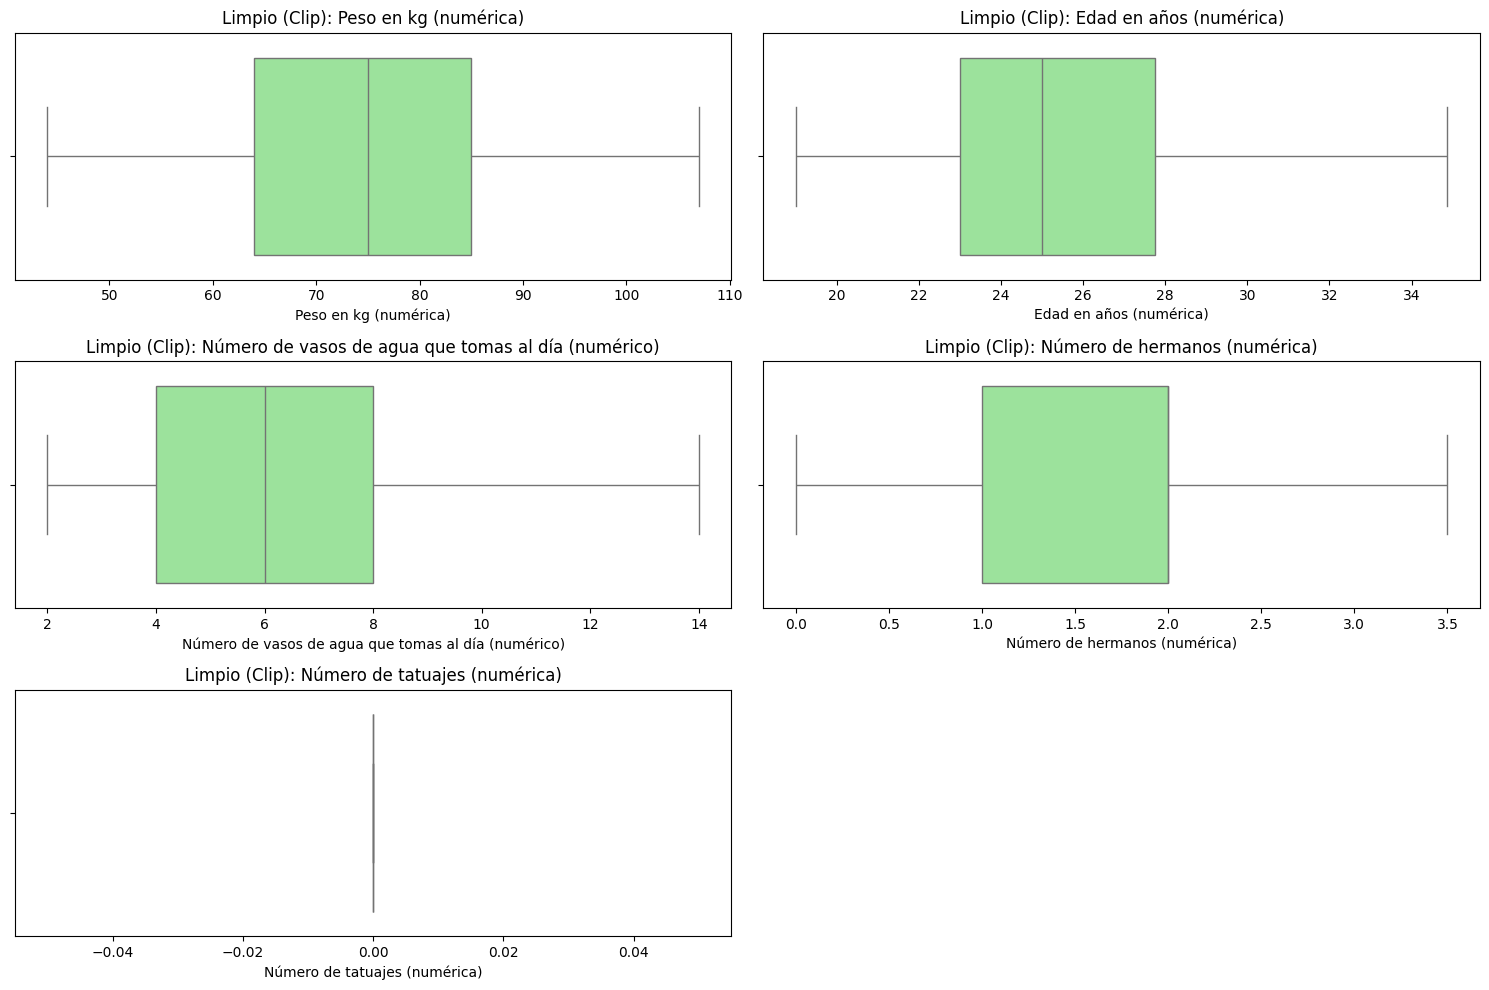

In [45]:
# Hacemos una copia para no alterar el original directamente
df_sin_outliers = df.copy()

#Aplicamos el tratamiento (Clip)
for col in numeric_cols:
    lower = Q1[col] - 1.5 * IQR[col]
    upper = Q3[col] + 1.5 * IQR[col]
    df_sin_outliers[col] = df_sin_outliers[col].clip(lower, upper)

#Visualización DESPUÉS de la limpieza
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(len(numeric_cols) // 2 + 1, 2, i + 1)
    sns.boxplot(x=df_sin_outliers[col], color='lightgreen')
    plt.title(f'Limpio (Clip): {col}')

plt.tight_layout()
plt.show()

#### DETECCIÓN Y REMOCIÓN DE VARIABLE POCO POBLADAS

In [46]:
missing_ratio = df_sin_outliers.isnull().mean()
missing_ratio.sort_values(ascending=False)

Peso en kg (numérica)                                 0.06763285
Número de tatuajes (numérica)                         0.01449275
Número de hermanos (numérica)                         0.00966184
Edad en años (numérica)                               0.00483092
Número de vasos de agua que tomas al día (numérico)   0.00483092
Estatura en metros (numérica)                         0.00483092
dia                                                   0.00000000
chile_pica                                            0.00000000
quesadilla_queso                                      0.00000000
team_frio                                             0.00000000
actividad_fisica                                      0.00000000
introvertido                                          0.00000000
color_primario_favorito_amarillo                      0.00000000
color_primario_favorito_azul                          0.00000000
color_primario_favorito_otros                         0.00000000
color_primario_favorito_r

In [47]:
low_populated_vars = missing_ratio[missing_ratio > 0.30].index.tolist()
low_populated_vars

[]

In [48]:
df_sin_outliers.drop(columns=low_populated_vars, inplace=True)

#### DETECCIÓN Y REMOCIÓN DE VARIABLES UNITARIAS (UNARIAS)


In [49]:
list_columns = [
    col for col in df_sin_outliers.columns
    if df_sin_outliers[col].apply(lambda x: isinstance(x, list)).any()
]
unary_vars = [
    col for col in df_sin_outliers.columns
    if col not in list_columns and df_sin_outliers[col].nunique(dropna=True) == 1
]
unary_vars

['Número de tatuajes (numérica)']

In [50]:
if "Número de tatuajes (numérica)" in ls_disc:
    ls_disc.remove("Número de tatuajes (numérica)")

In [51]:
df_sin_outliers.drop(columns=unary_vars, inplace=True)
df_sin_outliers.head()

,Edad en años (numérica),Estatura en metros (numérica),Peso en kg (numérica),Número de vasos de agua que tomas al día (numérico),Número de hermanos (numérica),dia,chile_pica,quesadilla_queso,team_frio,actividad_fisica,introvertido,color_primario_favorito_amarillo,color_primario_favorito_azul,color_primario_favorito_otros,color_primario_favorito_rojo,color_primario_favorito_verde,mascota_favorita_gato,mascota_favorita_otros,mascota_favorita_perro
0,29.00000000,1.92000000,107.00000000,6.00000000,2.00000000,0,1,1,0,0,1,0,1,0,0,0,0,0,1
1,26.00000000,1.57000000,58.00000000,5.00000000,0.00000000,0,1,1,0,0,1,0,1,0,0,0,0,0,1
2,25.00000000,1.71000000,78.00000000,3.00000000,1.00000000,0,1,1,0,1,1,0,1,0,0,0,0,0,1
3,27.00000000,1.78000000,87.00000000,4.00000000,1.00000000,0,1,0,0,0,1,0,0,0,1,0,0,0,1
4,23.00000000,1.70000000,76.00000000,4.00000000,2.00000000,0,0,1,0,1,1,0,1,0,0,0,1,0,0


In [52]:
df_sin_outliers.std()

Edad en años (numérica)                                4.01362310
Estatura en metros (numérica)                          0.09255635
Peso en kg (numérica)                                 13.61121246
Número de vasos de agua que tomas al día (numérico)    2.64239288
Número de hermanos (numérica)                          0.92999848
dia                                                    0.47080718
chile_pica                                             0.45700670
quesadilla_queso                                       0.43194515
team_frio                                              0.41994280
actividad_fisica                                       0.41011094
introvertido                                           0.48696724
color_primario_favorito_amarillo                       0.25988275
color_primario_favorito_azul                           0.49862623
color_primario_favorito_otros                          0.28245442
color_primario_favorito_rojo                           0.41674756
color_prim

#### DETECCIÓN Y TRATAMIENTO DE VALORES AUSENTES

In [53]:
df_sin_outliers.isna().sum()

Edad en años (numérica)                                 1
Estatura en metros (numérica)                           1
Peso en kg (numérica)                                  14
Número de vasos de agua que tomas al día (numérico)     1
Número de hermanos (numérica)                           2
dia                                                     0
chile_pica                                              0
quesadilla_queso                                        0
team_frio                                               0
actividad_fisica                                        0
introvertido                                            0
color_primario_favorito_amarillo                        0
color_primario_favorito_azul                            0
color_primario_favorito_otros                           0
color_primario_favorito_rojo                            0
color_primario_favorito_verde                           0
mascota_favorita_gato                                   0
mascota_favori

In [54]:
# Columnas numéricas 
num_cols = ls_cont + ls_disc

# Imputer para numéricas (mediana)
imputer_num = SimpleImputer(strategy='median')

# Aplicar imputación
df_sin_outliers[num_cols] = imputer_num.fit_transform(df_sin_outliers[num_cols])

In [55]:
df_sin_outliers.isna().sum()

Edad en años (numérica)                                0
Estatura en metros (numérica)                          1
Peso en kg (numérica)                                  0
Número de vasos de agua que tomas al día (numérico)    0
Número de hermanos (numérica)                          0
dia                                                    0
chile_pica                                             0
quesadilla_queso                                       0
team_frio                                              0
actividad_fisica                                       0
introvertido                                           0
color_primario_favorito_amarillo                       0
color_primario_favorito_azul                           0
color_primario_favorito_otros                          0
color_primario_favorito_rojo                           0
color_primario_favorito_verde                          0
mascota_favorita_gato                                  0
mascota_favorita_otros         

In [56]:
# Eliminar filas donde el target es nulo
df_final = df_sin_outliers.dropna(subset=target)

# Verificar que ya no existan nulos en todo el dataset
df_final.isna().sum()

Edad en años (numérica)                                0
Estatura en metros (numérica)                          0
Peso en kg (numérica)                                  0
Número de vasos de agua que tomas al día (numérico)    0
Número de hermanos (numérica)                          0
dia                                                    0
chile_pica                                             0
quesadilla_queso                                       0
team_frio                                              0
actividad_fisica                                       0
introvertido                                           0
color_primario_favorito_amarillo                       0
color_primario_favorito_azul                           0
color_primario_favorito_otros                          0
color_primario_favorito_rojo                           0
color_primario_favorito_verde                          0
mascota_favorita_gato                                  0
mascota_favorita_otros         

In [57]:
df_para_separar = df_final

## Regresión Lineal

### Separación de sets

In [58]:
X = df_final[[x for x in df_final.columns if x!="Estatura en metros (numérica)"]]
y = df_final[target]
X.shape

(206, 18)

In [59]:
X.sample(5)

,Edad en años (numérica),Peso en kg (numérica),Número de vasos de agua que tomas al día (numérico),Número de hermanos (numérica),dia,chile_pica,quesadilla_queso,team_frio,actividad_fisica,introvertido,color_primario_favorito_amarillo,color_primario_favorito_azul,color_primario_favorito_otros,color_primario_favorito_rojo,color_primario_favorito_verde,mascota_favorita_gato,mascota_favorita_otros,mascota_favorita_perro
104,34.87500000,87.00000000,6.00000000,1.00000000,0,1,1,1,1,1,0,1,0,0,0,0,0,1
42,20.00000000,80.00000000,2.00000000,2.00000000,1,1,1,1,1,1,1,0,0,0,0,1,0,0
125,23.00000000,52.00000000,10.00000000,1.00000000,0,0,1,1,1,0,0,1,0,0,0,0,0,1
186,31.00000000,57.00000000,12.00000000,3.00000000,1,0,1,1,1,1,0,1,0,0,0,0,0,1
121,23.00000000,73.00000000,14.00000000,2.00000000,0,1,1,1,1,0,0,1,0,0,0,0,0,1


In [60]:
y.sample(5)

,Estatura en metros (numérica)
163,1.77000000
102,1.63000000
135,1.78000000
49,1.63000000
192,1.74000000


### Selección de variables

In [61]:
kb = SelectKBest(k="all", score_func=f_regression)

In [62]:
kb.fit(X, y)

/home/jimmii/Documentos/DiplomadoCienciaDeDatos2025-2026/Modulo2/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function f_r...x7436179958a0>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",'all'


In [63]:
df_scores = pd.DataFrame(data=zip(X.columns, kb.scores_), columns=["feature", "score"]).set_index("feature").sort_values(by="score", ascending=False)
df_scores

,score
feature,
Peso en kg (numérica),419.34059719
color_primario_favorito_amarillo,8.96844518
mascota_favorita_perro,6.64907633
chile_pica,5.31213677
mascota_favorita_gato,4.01247884
Edad en años (numérica),3.31208322
Número de hermanos (numérica),2.62169674
color_primario_favorito_verde,2.11961285
quesadilla_queso,1.49498651


In [64]:
fig = px.bar(df_scores.reset_index().rename(columns={"index": "feature"}), x="feature", y="score", title="Feature scores")
fig.update_layout(xaxis={'categoryorder':'total descending'})
fig.show()

In [65]:
ls_best = [x for x in df_scores.head(15).index ]
len(ls_best)

15

In [66]:
ls_best

['Peso en kg (numérica)',
 'color_primario_favorito_amarillo',
 'mascota_favorita_perro',
 'chile_pica',
 'mascota_favorita_gato',
 'Edad en años (numérica)',
 'Número de hermanos (numérica)',
 'color_primario_favorito_verde',
 'quesadilla_queso',
 'mascota_favorita_otros',
 'Número de vasos de agua que tomas al día (numérico)',
 'color_primario_favorito_azul',
 'dia',
 'color_primario_favorito_rojo',
 'actividad_fisica']

### Modelado

#### Train-test split

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X[ls_best], y, test_size=0.3)

#### Escalamiento

In [68]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Entrenamiento del modelo

In [69]:
linreg = LinearRegression()

In [70]:
linreg.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [71]:
linreg.score(X_train_scaled, y_train)

0.7249622326907709

#### Cross-validation

In [72]:
ls_res = cross_val_score(X=X_train_scaled, y=y_train, estimator=linreg, cv=4, scoring="r2", n_jobs=-1)
ls_res

array([0.50770115, 0.71023312, 0.65912706, 0.58767626])

In [73]:
ls_res.mean(), ls_res.std()

(np.float64(0.6161843980469339), np.float64(0.07627345948047541))

En promedio, el modelo explica el 61.6% de la variabilidad de la estatura. Para un modelo de comportamiento humano (estatura), es un resultado aceptable, aunque indica que hay factores que el modelo aún no captura del todo.

Estabilidad: El std de 0.076 es bajo. Esto es bueno; significa que el modelo es estable y no cambia drásticamente dependiendo de los datos que use para entrenar.

#### Validación en test

In [74]:
linreg.score(X_test_scaled, y_test)

0.6190292961386313


En entrenamiento (CV): Obtuvimos un promedio de 0.6161.

En prueba (Test): Obtuvimoa 0.6190.

¿Qué nos dice esto? Que el modelo es altamente confiable. Como el puntaje de prueba es casi igual al de entrenamiento, sabemos que el modelo no se "memorizó" los datos (no hay overfitting). Lo que aprendió con un grupo de personas, lo está aplicando igual de bien con personas nuevas.

#### Predicción de test

In [75]:
y_pred = linreg.predict(X_test_scaled)
y_pred

array([[1.58733301],
       [1.62976157],
       [1.71818918],
       [1.68369358],
       [1.81735312],
       [1.62478269],
       [1.57890117],
       [1.57614823],
       [1.66807935],
       [1.75990343],
       [1.80868734],
       [1.60252024],
       [1.63757738],
       [1.80099857],
       [1.71972711],
       [1.7611157 ],
       [1.60583849],
       [1.77195081],
       [1.64859565],
       [1.71350181],
       [1.72431727],
       [1.68784046],
       [1.6552472 ],
       [1.85794783],
       [1.81033916],
       [1.69721969],
       [1.81544103],
       [1.71930776],
       [1.67993327],
       [1.72697159],
       [1.82632027],
       [1.72174627],
       [1.68031388],
       [1.80277417],
       [1.72005571],
       [1.74878854],
       [1.70925962],
       [1.74752724],
       [1.77737228],
       [1.63564349],
       [1.64383427],
       [1.63019162],
       [1.68327235],
       [1.78200083],
       [1.65453978],
       [1.6190139 ],
       [1.79710091],
       [1.631

### Métricas de performance

#### R²

In [76]:
r2_score(y_true=y_test, y_pred=y_pred)

0.6190292961386313

El modelo explica aproximadamente el 61.9% de la variabilidad de la estatura. Es un ajuste moderadamente bueno para datos biológicos/sociales; indica que el peso y las demás variables tienen una relación sólida con la estatura, aunque hay un 38% que depende de factores no medidos (como la genética)


#### PEMA

In [77]:
pema = mean_absolute_percentage_error(y_true=y_test, y_pred=y_pred)

In [78]:
f"{pema:,.2%}"

'2.54%'

El error porcentual es muy bajo, lo que confirma que el modelo es bastante preciso en términos relativos

#### MAE

In [79]:
mean_absolute_error(y_true=y_test, y_pred=y_pred)

0.044292146961327765

El Error Absoluto Medio es de aprox 4.42 centímetros. Esto significa que, en promedio, las predicciones del fallan por apenas unos 4 centímetros respecto a la estatura real.

In [80]:
y_pred

array([[1.58733301],
       [1.62976157],
       [1.71818918],
       [1.68369358],
       [1.81735312],
       [1.62478269],
       [1.57890117],
       [1.57614823],
       [1.66807935],
       [1.75990343],
       [1.80868734],
       [1.60252024],
       [1.63757738],
       [1.80099857],
       [1.71972711],
       [1.7611157 ],
       [1.60583849],
       [1.77195081],
       [1.64859565],
       [1.71350181],
       [1.72431727],
       [1.68784046],
       [1.6552472 ],
       [1.85794783],
       [1.81033916],
       [1.69721969],
       [1.81544103],
       [1.71930776],
       [1.67993327],
       [1.72697159],
       [1.82632027],
       [1.72174627],
       [1.68031388],
       [1.80277417],
       [1.72005571],
       [1.74878854],
       [1.70925962],
       [1.74752724],
       [1.77737228],
       [1.63564349],
       [1.64383427],
       [1.63019162],
       [1.68327235],
       [1.78200083],
       [1.65453978],
       [1.6190139 ],
       [1.79710091],
       [1.631

### Interpretación

In [81]:
linreg.intercept_

array([1.69006944])

In [82]:
y_train.mean()

Estatura en metros (numérica)   1.69006944
dtype: float64

In [83]:
linreg.coef_

array([[ 7.00530016e-02, -2.10868209e-03,  5.00764390e-03,
         9.25351962e-03, -2.48376075e-03, -6.08245816e-03,
        -2.14187927e-03,  4.88062835e-03,  6.16444309e-03,
        -4.68256491e-03, -4.28949850e-03,  2.44877120e-03,
         1.40207333e-02, -1.53262133e-05, -3.42619248e-03]])

##### Interpretación de Betas

La más importante es la primera (Peso), que tiene un peso de 0.07005. Variable "Peso en kg" ($\beta_1 = 0.07005$): Al analizar los coeficientes del modelo estandarizado, se identifica que el Peso es la variable con mayor poder predictivo sobre la estatura. Al presentar el coeficiente positivo más alto (0.07), confirmamos una relación directamente proporcional: a mayor peso, el modelo predice una mayor estatura, manteniendo el resto de las variables constantes.

Intercepto ($\beta_0 = 1.69$): Representa la estatura base teórica. Curiosamente, coincide con la media (y_train.mean()), lo cual es común en modelos bien centrados.

Otras variables: Hay coeficientes muy pequeños (como -2.10e-03 o 5.00e-03). Esto indica que esas variables tienen un impacto casi nulo en la estatura comparado con el peso.

In [84]:
df_res = pd.DataFrame(data=zip(X_train.columns, linreg.coef_), columns=["feature", "weight"])

In [85]:
df_res.sort_values(by="weight")

,feature,weight
0,Peso en kg (numérica),"[0.07005300158269029, -0.0021086820874609002, ..."


In [86]:
y_train.describe(percentiles=[x/10 for x in range(10)])

,Estatura en metros (numérica)
count,144.00000000
mean,1.69006944
std,0.09071971
min,1.50000000
0%,1.50000000
10%,1.56300000
20%,1.60000000
30%,1.64000000
40%,1.68000000
50%,1.70000000


### Predicción final

In [87]:
X_final = df_final[X_train.columns]

In [88]:
X_final_scaled = scaler.transform(X_final)

In [89]:
df_final["y_hat"] = linreg.predict(X_final_scaled)


/tmp/ipykernel_27002/2831465693.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [90]:
df_final[[target[0], "y_hat"]].sample(10)

,Estatura en metros (numérica),y_hat
103,1.61000000,1.70623663
205,1.70000000,1.69689814
63,1.75000000,1.73964742
55,1.74000000,1.68654544
61,1.85000000,1.81735312
72,1.56000000,1.59528820
197,1.80000000,1.86451639
99,1.68000000,1.70584569
109,1.80000000,1.80868734
75,1.76000000,1.78011388


En el registro 72, la estatura real es 1.56 y el modelo predijo 1.59. La cercanía entre y_hat y la estatura real confirma visualmente que el error de ~4cm (MAE) es consistente.

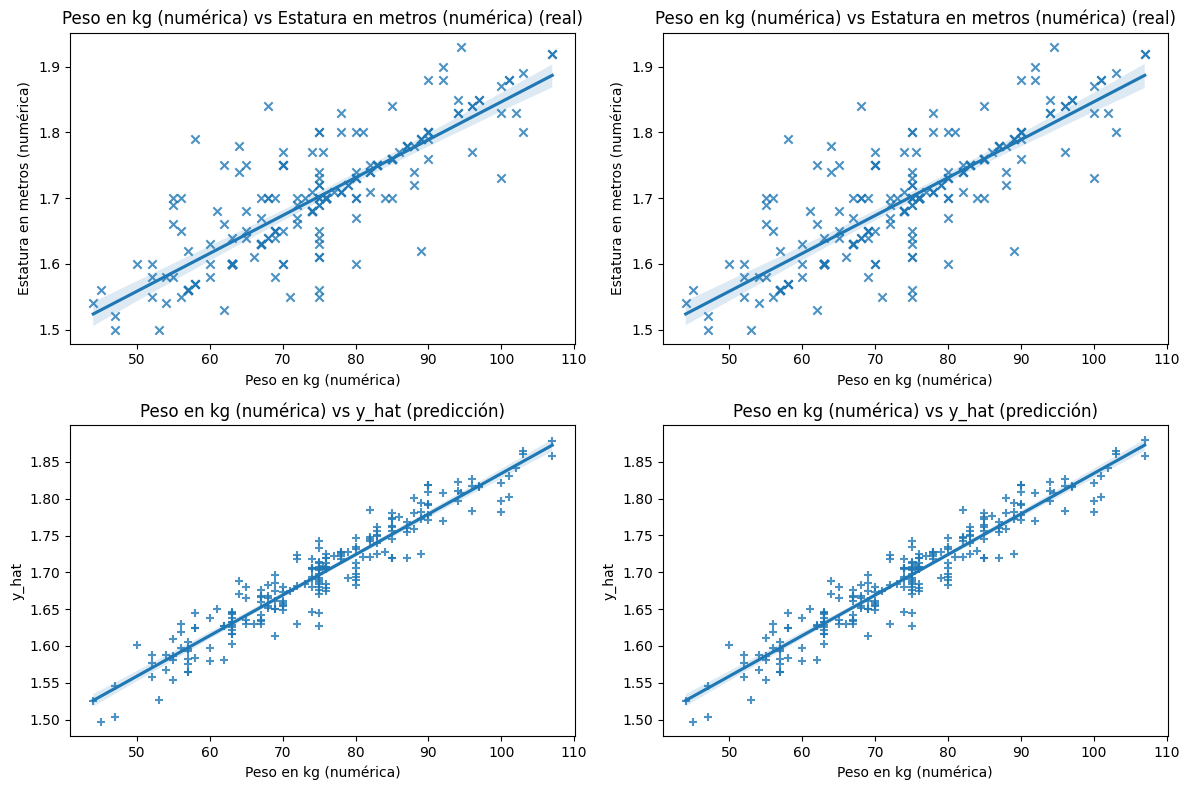

In [91]:

target = target[0]

plt.figure(figsize=(12,8))

# Ordenar features por importancia (valor absoluto del peso)
df_res_sorted = (
    df_res
    .assign(abs_weight=df_res["weight"].abs())
    .sort_values(by="abs_weight", ascending=False)
)

features = df_res_sorted["feature"].tolist()

# Selección segura de variables
x_top = features[0]                 # más importante
x_low = features[-1]                # menos importante

# X_top vs target real
plt.subplot(2,2,1)
sns.regplot(x=x_top, y=target, data=df_final, marker='x')
plt.title(f"{x_top} vs {target} (real)")

# X_low vs target real
plt.subplot(2,2,2)
sns.regplot(x=x_low, y=target, data=df_final, marker='x')
plt.title(f"{x_low} vs {target} (real)")

# X_top vs predicción
plt.subplot(2,2,3)
sns.regplot(x=x_top, y="y_hat", data=df_final, marker='+')
plt.title(f"{x_top} vs y_hat (predicción)")

# X_low vs predicción
plt.subplot(2,2,4)
sns.regplot(x=x_low, y="y_hat", data=df_final, marker='+')
plt.title(f"{x_low} vs y_hat (predicción)")

plt.tight_layout()
plt.show()



## Regresión Logística & Credit Scoring

### Creación de TAD

In [197]:
ls_cat

['dia',
 'chile_pica',
 'quesadilla_queso',
 'team_frio',
 'introvertido',
 'color_primario_favorito_amarillo',
 'color_primario_favorito_azul',
 'color_primario_favorito_otros',
 'color_primario_favorito_rojo',
 'color_primario_favorito_verde',
 'mascota_favorita_gato',
 'mascota_favorita_otros',
 'mascota_favorita_perro']

In [206]:
df_para_separar

,Edad en años (numérica),Estatura en metros (numérica),Peso en kg (numérica),Número de vasos de agua que tomas al día (numérico),Número de hermanos (numérica),dia,chile_pica,quesadilla_queso,team_frio,actividad_fisica,introvertido,color_primario_favorito_amarillo,color_primario_favorito_azul,color_primario_favorito_otros,color_primario_favorito_rojo,color_primario_favorito_verde,mascota_favorita_gato,mascota_favorita_otros,mascota_favorita_perro,y_hat
0,29.00000000,1.92000000,107.00000000,6.00000000,2.00000000,0,1,1,0,0,1,0,1,0,0,0,0,0,1,1.87894326
1,26.00000000,1.57000000,58.00000000,5.00000000,0.00000000,0,1,1,0,0,1,0,1,0,0,0,0,0,1,1.62478269
2,25.00000000,1.71000000,78.00000000,3.00000000,1.00000000,0,1,1,0,1,1,0,1,0,0,0,0,0,1,1.72712387
3,27.00000000,1.78000000,87.00000000,4.00000000,1.00000000,0,1,0,0,0,1,0,0,0,1,0,0,0,1,1.75990343
4,23.00000000,1.70000000,76.00000000,4.00000000,2.00000000,0,0,1,0,1,1,0,1,0,0,0,1,0,0,1.67866719
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202,24.00000000,1.60000000,52.00000000,6.00000000,1.00000000,1,0,1,1,1,0,0,0,1,0,0,0,0,1,1.58733301
203,22.00000000,1.55000000,71.00000000,6.00000000,1.00000000,0,1,0,1,1,1,0,1,0,0,0,0,0,1,1.67486701
204,32.00000000,1.60000000,60.00000000,4.00000000,2.00000000,0,1,0,1,1,1,0,0,1,0,0,1,0,0,1.57890117
205,25.00000000,1.70000000,69.00000000,4.00000000,2.00000000,1,1,1,1,0,1,0,1,0,0,0,1,0,0,1.69689814


In [207]:
df=df_para_separar.copy()
df.drop(columns=["y_hat"], inplace=True)
X_logistica = df[[x for x in df.columns if x!="actividad_fisica"]]
X_logistica .sample(5)

,Edad en años (numérica),Estatura en metros (numérica),Peso en kg (numérica),Número de vasos de agua que tomas al día (numérico),Número de hermanos (numérica),dia,chile_pica,quesadilla_queso,team_frio,introvertido,color_primario_favorito_amarillo,color_primario_favorito_azul,color_primario_favorito_otros,color_primario_favorito_rojo,color_primario_favorito_verde,mascota_favorita_gato,mascota_favorita_otros,mascota_favorita_perro
29,23.00000000,1.67000000,72.00000000,5.00000000,1.00000000,0,0,1,1,1,0,1,0,0,0,0,0,1
28,24.00000000,1.60000000,63.00000000,8.00000000,1.00000000,1,0,1,1,0,1,0,0,0,0,0,0,1
192,26.00000000,1.74000000,80.00000000,8.00000000,2.00000000,0,1,1,1,0,1,0,0,0,0,0,0,1
120,32.00000000,1.71000000,74.00000000,4.00000000,3.00000000,0,1,0,1,1,0,1,0,0,0,0,1,0
150,23.00000000,1.63000000,60.00000000,8.00000000,2.00000000,1,1,0,1,1,0,1,0,0,0,0,0,1


In [208]:
y_logis = df["actividad_fisica"]
y_logis.sample(5)
target = "actividad_fisica"

In [209]:
target

'actividad_fisica'

#### Discretización

In [211]:
ls_num = ls_cont + ls_disc
for n_bins in range(2, 10):
    for var in ls_num:
        df[f"C_{var}"] = pd.qcut(df[var], q=n_bins, duplicates="drop").cat.add_categories(["Missing"]).fillna("Missing").astype(str)
    ls_discretized = [x for x in df.columns if x.startswith("C_")]
    df_iv = pd.DataFrame(columns=["iv"])
    for var in ls_discretized:
        df_iv.loc[var, "iv"] = IV(df = df, var = var, tgt = target)
    print(f"{n_bins} bins")
    display(df_iv)

2 bins


,iv
C_Peso en kg (numérica),0.00041234
C_Edad en años (numérica),0.00906804
C_Número de vasos de agua que tomas al día (numérico),0.20235576
C_Número de hermanos (numérica),0.00478577


3 bins


,iv
C_Peso en kg (numérica),0.07462569
C_Edad en años (numérica),0.02950344
C_Número de vasos de agua que tomas al día (numérico),0.18685333
C_Número de hermanos (numérica),0.03019078


4 bins


,iv
C_Peso en kg (numérica),0.15876912
C_Edad en años (numérica),0.03456287
C_Número de vasos de agua que tomas al día (numérico),0.22060415
C_Número de hermanos (numérica),0.03019078


5 bins


,iv
C_Peso en kg (numérica),0.20052291
C_Edad en años (numérica),0.18855547
C_Número de vasos de agua que tomas al día (numérico),0.20129439
C_Número de hermanos (numérica),0.03019078


6 bins


,iv
C_Peso en kg (numérica),0.12673499
C_Edad en años (numérica),0.20534500
C_Número de vasos de agua que tomas al día (numérico),0.23519054
C_Número de hermanos (numérica),0.11786486


7 bins


,iv
C_Peso en kg (numérica),0.16545660
C_Edad en años (numérica),0.22637165
C_Número de vasos de agua que tomas al día (numérico),0.25026102
C_Número de hermanos (numérica),0.11786486


8 bins


/home/jimmii/Documentos/DiplomadoCienciaDeDatos2025-2026/Modulo2/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning:

divide by zero encountered in log



,iv
C_Peso en kg (numérica),0.25104720
C_Edad en años (numérica),0.23826557
C_Número de vasos de agua que tomas al día (numérico),inf
C_Número de hermanos (numérica),0.11786486


9 bins


/home/jimmii/Documentos/DiplomadoCienciaDeDatos2025-2026/Modulo2/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning:

divide by zero encountered in log



,iv
C_Peso en kg (numérica),0.62577765
C_Edad en años (numérica),0.24012017
C_Número de vasos de agua que tomas al día (numérico),inf
C_Número de hermanos (numérica),0.11786486


In [217]:
for var in ls_num:
    df[f"C_{var}"] = pd.qcut(df[var], q=6, duplicates="drop").cat.add_categories(["Missing"]).fillna("Missing")

In [218]:
ls_cat =["dia","chile_pica","quesadilla_queso","team_frio","introvertido","color_primario_favorito_amarillo","color_primario_favorito_azul","color_primario_favorito_otros","color_primario_favorito_rojo","color_primario_favorito_verde","mascota_favorita_gato","mascota_favorita_otros","mascota_favorita_perro"]

#### IV

In [219]:
df_iv = pd.DataFrame(columns=["iv"])
for var in ls_discretized+ls_cat:
    df_iv.loc[var, "iv"] = IV(df = df, var = var, tgt = target)

/tmp/ipykernel_27002/3673014158.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_27002/3673014158.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_27002/3673014158.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_27002/3673014158.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=F

In [220]:
df_iv.sort_values(by="iv", ascending=False)

,iv
color_primario_favorito_otros,inf
C_Número de vasos de agua que tomas al día (numérico),0.23519054
C_Edad en años (numérica),0.20534500
introvertido,0.18381032
C_Peso en kg (numérica),0.12673499
C_Número de hermanos (numérica),0.11786486
color_primario_favorito_rojo,0.04534941
mascota_favorita_gato,0.04285217
chile_pica,0.03928630
team_frio,0.03907765


In [223]:
ls_best = ls_discretized + ls_cat
ls_best

['C_Peso en kg (numérica)',
 'C_Edad en años (numérica)',
 'C_Número de vasos de agua que tomas al día (numérico)',
 'C_Número de hermanos (numérica)',
 'dia',
 'chile_pica',
 'quesadilla_queso',
 'team_frio',
 'introvertido',
 'color_primario_favorito_amarillo',
 'color_primario_favorito_azul',
 'color_primario_favorito_otros',
 'color_primario_favorito_rojo',
 'color_primario_favorito_verde',
 'mascota_favorita_gato',
 'mascota_favorita_otros',
 'mascota_favorita_perro']

In [225]:
a_eliminar = [
    "color_primario_favorito_otros",
    "quesadilla_queso",
    "color_primario_favorito_azul",
    "color_primario_favorito_amarillo",
    "mascota_favorita_otros",
    "color_primario_favorito_verde"
]

ls_best = [x for x in ls_best if x not in a_eliminar]


In [226]:
ls_best

['C_Peso en kg (numérica)',
 'C_Edad en años (numérica)',
 'C_Número de vasos de agua que tomas al día (numérico)',
 'C_Número de hermanos (numérica)',
 'dia',
 'chile_pica',
 'team_frio',
 'introvertido',
 'color_primario_favorito_rojo',
 'mascota_favorita_gato',
 'mascota_favorita_perro']

#### WOE

In [227]:
for var in ls_best:
    df = WOE(df = df, var = var, tgt = target)

df

/tmp/ipykernel_27002/2034038935.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



actividad_fisica     evento no_evento    %evento  \
                                   count sum                               
C_Peso en kg (numérica)                                                    
(43.999, 62.0]                        36  28     28         8 0.17283951   
(62.0, 69.0]                          39  31     31         8 0.19135802   
(69.0, 75.0]                          39  31     31         8 0.19135802   
(75.0, 80.0]                          30  27     27         3 0.16666667   
(80.0, 87.833]                        27  20     20         7 0.12345679   
(87.833, 107.0]                       35  25     25        10 0.15432099   
Missing                                0   0      0         0 0.00000000   

                        %no_evento         WOE  
                                                
C_Peso en kg (numérica)                         
(43.999, 62.0]          0.18181818  0.05064373  
(62.0, 69.0]            0.18181818 -0.05113896  
(69.0, 75.0]            0.18181818 -0.05113896  
(75.0, 80.0]            0.06818182 -0.89381788  
(80.0, 87.833]          0.15909091  0.25358458  
(87.833, 107.0]         0.22727273  0.38711597  
Missing                 0.00000000         NaN

/tmp/ipykernel_27002/2034038935.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



actividad_fisica     evento no_evento    %evento  \
                                     count sum                               
C_Edad en años (numérica)                                                    
(18.999, 22.0]                          42  30     30        12 0.18518519   
(22.0, 24.0]                            56  50     50         6 0.30864198   
(24.0, 25.0]                            22  16     16         6 0.09876543   
(25.0, 27.0]                            35  27     27         8 0.16666667   
(27.0, 29.0]                            17  12     12         5 0.07407407   
(29.0, 34.875]                          34  27     27         7 0.16666667   
Missing                                  0   0      0         0 0.00000000   

                          %no_evento         WOE  
                                                  
C_Edad en años (numérica)                         
(18.999, 22.0]            0.27272727  0.38711597  
(22.0, 24.0]              0.13636364 -0.81685683  
(24.0, 25.0]              0.13636364  0.32257745  
(25.0, 27.0]              0.18181818  0.08701138  
(27.0, 29.0]              0.11363636  0.42793796  
(29.0, 34.875]            0.15909091 -0.04652002  
Missing                   0.00000000         NaN

/tmp/ipykernel_27002/2034038935.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



actividad_fisica      \
                                                              count sum   
C_Número de vasos de agua que tomas al día (num...                        
(1.999, 4.0]                                                     53  39   
(4.0, 5.0]                                                       34  23   
(5.0, 6.0]                                                       33  25   
(6.0, 8.0]                                                       55  47   
(8.0, 14.0]                                                      31  28   
Missing                                                           0   0   

                                                   evento no_evento  \
                                                                      
C_Número de vasos de agua que tomas al día (num...                    
(1.999, 4.0]                                           39        14   
(4.0, 5.0]                                             23        11   
(5.0, 6.0]                                             25         8   
(6.0, 8.0]                                             47         8   
(8.0, 14.0]                                            28         3   
Missing                                                 0         0   

                                                      %evento %no_evento  \
                                                                           
C_Número de vasos de agua que tomas al día (num...                         
(1.999, 4.0]                                       0.24074074 0.31818182   
(4.0, 5.0]                                         0.14197531 0.25000000   
(5.0, 6.0]                                         0.15432099 0.18181818   
(6.0, 8.0]                                         0.29012346 0.18181818   
(8.0, 14.0]                                        0.17283951 0.06818182   
Missing                                            0.00000000 0.00000000   

                                                           WOE  
                                                                
C_Número de vasos de agua que tomas al día (num...              
(1.999, 4.0]                                        0.27890238  
(4.0, 5.0]                                          0.56580776  
(5.0, 6.0]                                          0.16397242  
(6.0, 8.0]                                         -0.46729936  
(8.0, 14.0]                                        -0.93018552  
Missing                                                    NaN

/tmp/ipykernel_27002/2034038935.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



actividad_fisica     evento no_evento  \
                                           count sum                    
C_Número de hermanos (numérica)                                         
(-0.001, 1.0]                                 89  67     67        22   
(1.0, 2.0]                                    80  65     65        15   
(2.0, 3.0]                                    21  19     19         2   
(3.0, 3.5]                                    16  11     11         5   
Missing                                        0   0      0         0   

                                   %evento %no_evento         WOE  
                                                                   
C_Número de hermanos (numérica)                                    
(-0.001, 1.0]                   0.41358025 0.50000000  0.18975654  
(1.0, 2.0]                      0.40123457 0.34090909 -0.16293037  
(2.0, 3.0]                      0.11728395 0.04545455 -0.94788510  
(3.0, 3.5]                      0.06790123 0.11363636  0.51494934  
Missing                         0.00000000 0.00000000         NaN

actividad_fisica      evento no_evento    %evento %no_evento         WOE
               count  sum                                                   
dia                                                                         
0                138  106    106        32 0.65432099 0.72727273  0.10570351
1                 68   56     56        12 0.34567901 0.27272727 -0.23703834

actividad_fisica      evento no_evento    %evento %no_evento  \
                      count  sum                                          
chile_pica                                                                
0                        60   44     44        16 0.27160494 0.36363636   
1                       146  118    118        28 0.72839506 0.63636364   

                   WOE  
                        
chile_pica              
0           0.29180579  
1          -0.13507341

actividad_fisica      evento no_evento    %evento %no_evento  \
                     count  sum                                          
team_frio                                                                
0                       47   34     34        13 0.20987654 0.29545455   
1                      159  128    128        31 0.79012346 0.70454545   

                  WOE  
                       
team_frio              
0          0.34199553  
1         -0.11463636

actividad_fisica     evento no_evento    %evento %no_evento  \
                        count sum                                          
introvertido                                                               
0                          79  69     69        10 0.42592593 0.22727273   
1                         127  93     93        34 0.57407407 0.77272727   

                     WOE  
                          
introvertido              
0            -0.62811471  
1             0.29716773

actividad_fisica      evento no_evento  \
                                        count  sum                    
color_primario_favorito_rojo                                          
0                                         160  129    129        31   
1                                          46   33     33        13   

                                %evento %no_evento         WOE  
                                                                
color_primario_favorito_rojo                                    
0                            0.79629630 0.70454545 -0.12241850  
1                            0.20370370 0.29545455  0.37184850

actividad_fisica      evento no_evento    %evento  \
                                 count  sum                               
mascota_favorita_gato                                                     
0                                  151  122    122        29 0.75308642   
1                                   55   40     40        15 0.24691358   

                      %no_evento         WOE  
                                              
mascota_favorita_gato                         
0                     0.65909091 -0.13331851  
1                     0.34090909  0.32257745

actividad_fisica      evento no_evento    %evento  \
                                  count  sum                               
mascota_favorita_perro                                                     
0                                    74   55     55        19 0.33950617   
1                                   132  107    107        25 0.66049383   

                       %no_evento         WOE  
                                               
mascota_favorita_perro                         
0                      0.43181818  0.24051250  
1                      0.56818182 -0.15054631

,Edad en años (numérica),Estatura en metros (numérica),Peso en kg (numérica),Número de vasos de agua que tomas al día (numérico),Número de hermanos (numérica),dia,chile_pica,quesadilla_queso,team_frio,actividad_fisica,introvertido,color_primario_favorito_amarillo,color_primario_favorito_azul,color_primario_favorito_otros,color_primario_favorito_rojo,color_primario_favorito_verde,mascota_favorita_gato,mascota_favorita_otros,mascota_favorita_perro,C_Peso en kg (numérica),C_Edad en años (numérica),C_Número de vasos de agua que tomas al día (numérico),C_Número de hermanos (numérica),W_C_Peso en kg (numérica),W_C_Edad en años (numérica),W_C_Número de vasos de agua que tomas al día (numérico),W_C_Número de hermanos (numérica),W_dia,W_chile_pica,W_team_frio,W_introvertido,W_color_primario_favorito_rojo,W_mascota_favorita_gato,W_mascota_favorita_perro
0,29.00000000,1.92000000,107.00000000,6.00000000,2.00000000,0,1,1,0,0,1,0,1,0,0,0,0,0,1,"(87.833, 107.0]","(27.0, 29.0]","(5.0, 6.0]","(1.0, 2.0]",0.38711597,0.42793796,0.16397242,-0.16293037,0.10570351,-0.13507341,0.34199553,0.29716773,-0.12241850,-0.13331851,-0.15054631
1,26.00000000,1.57000000,58.00000000,5.00000000,0.00000000,0,1,1,0,0,1,0,1,0,0,0,0,0,1,"(43.999, 62.0]","(25.0, 27.0]","(4.0, 5.0]","(-0.001, 1.0]",0.05064373,0.08701138,0.56580776,0.18975654,0.10570351,-0.13507341,0.34199553,0.29716773,-0.12241850,-0.13331851,-0.15054631
2,25.00000000,1.71000000,78.00000000,3.00000000,1.00000000,0,1,1,0,1,1,0,1,0,0,0,0,0,1,"(75.0, 80.0]","(24.0, 25.0]","(1.999, 4.0]","(-0.001, 1.0]",-0.89381788,0.32257745,0.27890238,0.18975654,0.10570351,-0.13507341,0.34199553,0.29716773,-0.12241850,-0.13331851,-0.15054631
3,27.00000000,1.78000000,87.00000000,4.00000000,1.00000000,0,1,0,0,0,1,0,0,0,1,0,0,0,1,"(80.0, 87.833]","(25.0, 27.0]","(1.999, 4.0]","(-0.001, 1.0]",0.25358458,0.08701138,0.27890238,0.18975654,0.10570351,-0.13507341,0.34199553,0.29716773,0.37184850,-0.13331851,-0.15054631
4,23.00000000,1.70000000,76.00000000,4.00000000,2.00000000,0,0,1,0,1,1,0,1,0,0,0,1,0,0,"(75.0, 80.0]","(22.0, 24.0]","(1.999, 4.0]","(1.0, 2.0]",-0.89381788,-0.81685683,0.27890238,-0.16293037,0.10570351,0.29180579,0.34199553,0.29716773,-0.12241850,0.32257745,0.24051250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201,24.00000000,1.60000000,52.00000000,6.00000000,1.00000000,1,0,1,1,1,0,0,0,1,0,0,0,0,1,"(43.999, 62.0]","(22.0, 24.0]","(5.0, 6.0]","(-0.001, 1.0]",0.05064373,-0.81685683,0.16397242,0.18975654,-0.23703834,0.29180579,-0.11463636,-0.62811471,-0.12241850,-0.13331851,-0.15054631
202,22.00000000,1.55000000,71.00000000,6.00000000,1.00000000,0,1,0,1,1,1,0,1,0,0,0,0,0,1,"(69.0, 75.0]","(18.999, 22.0]","(5.0, 6.0]","(-0.001, 1.0]",-0.05113896,0.38711597,0.16397242,0.18975654,0.10570351,-0.13507341,-0.11463636,0.29716773,-0.12241850,-0.13331851,-0.15054631
203,32.00000000,1.60000000,60.00000000,4.00000000,2.00000000,0,1,0,1,1,1,0,0,1,0,0,1,0,0,"(43.999, 62.0]","(29.0, 34.875]","(1.999, 4.0]","(1.0, 2.0]",0.05064373,-0.04652002,0.27890238,-0.16293037,0.10570351,-0.13507341,-0.11463636,0.29716773,-0.12241850,0.32257745,0.24051250
204,25.00000000,1.70000000,69.00000000,4.00000000,2.00000000,1,1,1,1,0,1,0,1,0,0,0,1,0,0,"(62.0, 69.0]","(24.0, 25.0]","(1.999, 4.0]","(1.0, 2.0]",-0.05113896,0.32257745,0.27890238,-0.16293037,-0.23703834,-0.13507341,-0.11463636,0.29716773,-0.12241850,0.32257745,0.24051250


### Modelado

In [254]:
ls_woe = [x for x in df.columns if x.startswith("W_")]

In [255]:
ls_woe

['W_C_Peso en kg (numérica)',
 'W_C_Edad en años (numérica)',
 'W_C_Número de vasos de agua que tomas al día (numérico)',
 'W_C_Número de hermanos (numérica)',
 'W_dia',
 'W_chile_pica',
 'W_team_frio',
 'W_introvertido',
 'W_color_primario_favorito_rojo',
 'W_mascota_favorita_gato',
 'W_mascota_favorita_perro']

#### Train-test split

In [256]:
X_train, X_test, y_train, y_test = train_test_split(df[ls_woe], df[target])

#### Regresión Logística

#### Generación de pipeline

In [257]:
pipe = Pipeline([
    ("imputador", SimpleImputer(strategy="median")),
    ("modelo", LogisticRegression(max_iter=1000))
])
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputador', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a

#### Cross validation

In [258]:
ls_scores = cross_val_score(pipe, X_train, y_train, cv=4)


In [259]:
ls_scores.mean(), ls_scores.std()

(np.float64(0.7729419703103915), np.float64(0.018854186245138817))

Un Accuracy ≈ 0.77 indica que el modelo tiene buena capacidad de discriminación.

Interpretación:

Si tomas una persona con actividad física = 1 y otra con actividad física = 0,

el modelo asigna un score mayor a la persona activa en ~77% de las veces.

Estabilidad del modelo (desviación estándar)

Std ≈ 0.019 es baja

Esto significa:

El desempeño del modelo es consistente entre folds

No depende excesivamente de un subconjunto específico



#### Entrenamiento del modelo

In [260]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputador', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a

#### Performance en test

In [261]:
pipe.score(X_test, y_test)

0.8269230769230769

Accuracy (Exactitud) del tu modelo aplicado a los datos que nunca había visto (el set de prueba) es de 82.6%

Indica que no hay Overfitting (sobreajuste). El modelo no se memorizó los datos de entrenamiento, sino que realmente aprendió patrones que funcionan con gente nueva.

#### Métricas de performance (ROC)

In [262]:
y_score = pipe.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(
    y_true=y_test,
    y_score=y_score
)

roc_auc

0.6309523809523809

El modelo presenta un sesgo hacia la clase mayoritaria. Aunque el Accuracy es aceptable (82%), la métrica ROC-AUC de 0.63 revela que el modelo aún tiene dificultades para discriminar eficazmente entre quienes si hacen actividad fisica y quienes no, esto puede estar pasando por Datos Desbalanceados. Sucede cuando en el set de datos hay muchísimos "Eventos" (digamos el 80%) y muy poquitos "No eventos" y el modelo aprendió que decir "Es Evento" casi siempre le da la razón (por eso el Accuracy de 0.82).

In [263]:
pipe[-1].intercept_

array([1.2647005])

Como el valor es positivo (1.26), significa que en la muestra hay una predisposición natural a hacer actividad física.Si no supiéramos nada de una persona (edad, peso, etc.), el modelo apostaría a que sí hace ejercicio.

#### Extracción de Betas y Alpha

In [266]:
pipe.named_steps


{'imputador': SimpleImputer(strategy='median'),
 'modelo': LogisticRegression(max_iter=1000)}

In [269]:
betas = pipe.named_steps["modelo"].coef_[0]
alpha = pipe.named_steps["modelo"].intercept_[0]


In [270]:
import pandas as pd

pd.DataFrame({
    "feature": pipe[:-1].get_feature_names_out(),
    "beta": betas
}).sort_values("beta", ascending=False)


,feature,beta
4,W_dia,0.13979932
5,W_chile_pica,-0.29757850
0,W_C_Peso en kg (numérica),-0.40061854
2,W_C_Número de vasos de agua que tomas al día (...,-0.48551357
8,W_color_primario_favorito_rojo,-0.55454238
6,W_team_frio,-0.58881770
3,W_C_Número de hermanos (numérica),-0.72347419
9,W_mascota_favorita_gato,-0.73755262
7,W_introvertido,-0.82072877
10,W_mascota_favorita_perro,-0.88902233


El tamaño (valor absoluto) del beta dice qué variable tiene más peso en la decisión final:

La Edad (-1.26): Es, por mucho, la variable que más influye. El modelo depende fuertemente de la edad para decidir si alguien hace ejercicio o no. Al ser un valor alto, es la variable con mayor poder predictivo real dentro de la regresión.

Mascota (Perro/Gato) e Introvertido (-0.73 a -0.88): Tienen un peso moderado. Curiosamente, ser introvertido o tener perro/gato está pesando más que el Peso físico en el modelo.

El Día (0.13): Es la única que mantiene una dirección positiva respecto al WoE original, pero su peso es casi nulo. Prácticamente no aporta nada a la decisión final.

Diagnóstico del AUC (0.63) explicado con estos Betas

Inconsistencia: Cuando los betas son negativos en un modelo WoE, suele haber multicolinealidad.

Sobreajuste a la Edad: El modelo está "apostando" casi todo a la Edad (-1.26) y despreciando un poco a las demás. Si la edad no es un predictor perfecto del ejercicio, el AUC no subirá.

#### Conversión a puntos

In [237]:
pdo = 15
base_score = 180
base_odds = 100
factor = pdo/np.log(2)
offset = base_score - (factor - np.log(base_odds))
m = len(ls_woe)

In [240]:
for feat, beta in zip(ls_woe, betas):
    df["P_" + feat[2:]] = df[feat].apply(lambda x:((-beta*x + (alpha/m))*factor) + (offset/m)).astype(int)

In [241]:
df

,Edad en años (numérica),Estatura en metros (numérica),Peso en kg (numérica),Número de vasos de agua que tomas al día (numérico),Número de hermanos (numérica),dia,chile_pica,quesadilla_queso,team_frio,actividad_fisica,introvertido,color_primario_favorito_amarillo,color_primario_favorito_azul,color_primario_favorito_otros,color_primario_favorito_rojo,color_primario_favorito_verde,mascota_favorita_gato,mascota_favorita_otros,mascota_favorita_perro,C_Peso en kg (numérica),C_Edad en años (numérica),C_Número de vasos de agua que tomas al día (numérico),C_Número de hermanos (numérica),W_C_Peso en kg (numérica),W_C_Edad en años (numérica),W_C_Número de vasos de agua que tomas al día (numérico),W_C_Número de hermanos (numérica),W_dia,W_chile_pica,W_team_frio,W_introvertido,W_color_primario_favorito_rojo,W_mascota_favorita_gato,W_mascota_favorita_perro,P_C_Peso en kg (numérica),P_C_Edad en años (numérica),P_C_Número de vasos de agua que tomas al día (numérico),P_C_Número de hermanos (numérica),P_dia,P_chile_pica,P_team_frio,P_introvertido,P_color_primario_favorito_rojo,P_mascota_favorita_gato,P_mascota_favorita_perro
0,29.00000000,1.92000000,107.00000000,6.00000000,2.00000000,0,1,1,0,0,1,0,1,0,0,0,0,0,1,"(87.833, 107.0]","(27.0, 29.0]","(5.0, 6.0]","(1.0, 2.0]",0.38711597,0.42793796,0.16397242,-0.16293037,0.10570351,-0.13507341,0.34199553,0.29716773,-0.12241850,-0.13331851,-0.15054631,23,23,18,13,17,15,21,25,15,14,15
1,26.00000000,1.57000000,58.00000000,5.00000000,0.00000000,0,1,1,0,0,1,0,1,0,0,0,0,0,1,"(43.999, 62.0]","(25.0, 27.0]","(4.0, 5.0]","(-0.001, 1.0]",0.05064373,0.08701138,0.56580776,0.18975654,0.10570351,-0.13507341,0.34199553,0.29716773,-0.12241850,-0.13331851,-0.15054631,18,18,21,21,17,15,21,25,15,14,15
2,25.00000000,1.71000000,78.00000000,3.00000000,1.00000000,0,1,1,0,1,1,0,1,0,0,0,0,0,1,"(75.0, 80.0]","(24.0, 25.0]","(1.999, 4.0]","(-0.001, 1.0]",-0.89381788,0.32257745,0.27890238,0.18975654,0.10570351,-0.13507341,0.34199553,0.29716773,-0.12241850,-0.13331851,-0.15054631,4,21,19,21,17,15,21,25,15,14,15
3,27.00000000,1.78000000,87.00000000,4.00000000,1.00000000,0,1,0,0,0,1,0,0,0,1,0,0,0,1,"(80.0, 87.833]","(25.0, 27.0]","(1.999, 4.0]","(-0.001, 1.0]",0.25358458,0.08701138,0.27890238,0.18975654,0.10570351,-0.13507341,0.34199553,0.29716773,0.37184850,-0.13331851,-0.15054631,21,18,19,21,17,15,21,25,23,14,15
4,23.00000000,1.70000000,76.00000000,4.00000000,2.00000000,0,0,1,0,1,1,0,1,0,0,0,1,0,0,"(75.0, 80.0]","(22.0, 24.0]","(1.999, 4.0]","(1.0, 2.0]",-0.89381788,-0.81685683,0.27890238,-0.16293037,0.10570351,0.29180579,0.34199553,0.29716773,-0.12241850,0.32257745,0.24051250,4,6,19,13,17,21,21,25,15,23,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201,24.00000000,1.60000000,52.00000000,6.00000000,1.00000000,1,0,1,1,1,0,0,0,1,0,0,0,0,1,"(43.999, 62.0]","(22.0, 24.0]","(5.0, 6.0]","(-0.001, 1.0]",0.05064373,-0.81685683,0.16397242,0.18975654,-0.23703834,0.29180579,-0.11463636,-0.62811471,-0.12241850,-0.13331851,-0.15054631,18,6,18,21,16,21,16,0,15,14,15
202,22.00000000,1.55000000,71.00000000,6.00000000,1.00000000,0,1,0,1,1,1,0,1,0,0,0,0,0,1,"(69.0, 75.0]","(18.999, 22.0]","(5.0, 6.0]","(-0.001, 1.0]",-0.05113896,0.38711597,0.16397242,0.18975654,0.10570351,-0.13507341,-0.11463636,0.29716773,-0.12241850,-0.13331851,-0.15054631,16,22,18,21,17,15,16,25,15,14,15
203,32.00000000,1.60000000,60.00000000,4.00000000,2.00000000,0,1,0,1,1,1,0,0,1,0,0,1,0,0,"(43.999, 62.0]","(29.0, 34.875]","(1.999, 4.0]","(1.0, 2.0]",0.05064373,-0.04652002,0.27890238,-0.16293037,0.10570351,-0.13507341,-0.11463636,0.29716773,-0.12241850,0.32257745,0.24051250,18,16,19,13,17,15,16,25,15,23,20
204,25.00000000,1.70000000,69.00000000,4.00000000,2.00000000,1,1,1,1,0,1,0,1,0,0,0,1,0,0,"(62.0, 69.0]","(24.0, 25.0]","(1.999, 4.0]","(1.0, 2.0]",-0.05113896,0.32257745,0.27890238,-0.16293037,-0.23703834,-0.13507341,-0.11463636,0.2971

### Scorecard

#### Obtención de puntos

In [271]:
df["score"] = df[[x for x in df.columns if x.startswith("P_")]].sum(axis = 1)
df["score"].describe()

count   206.00000000
mean    180.80582524
std      19.33557735
min     129.00000000
25%     167.00000000
50%     180.00000000
75%     195.00000000
max     226.00000000
Name: score, dtype: float64

In [272]:
px.histogram(df, x='score')

In [274]:
df[df['score']<180][target].mean()

np.float64(0.9175257731958762)

In [275]:
df["score_bin"] = pd.qcut(df["score"], q=10, duplicates="drop")


In [276]:
score_event = (
    df.groupby("score_bin")[target]
      .mean()
      .reset_index(name="event_rate")
)


/tmp/ipykernel_27002/3643833687.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [284]:
score_event = score_event.sort_values("score_bin")

score_event["score_bin"] = score_event["score_bin"].astype(str)

px.line(
    score_event,
    x="score_bin",
    y="event_rate",
    title="Score vs tasa de evento"
)

In [285]:
score_event


,score_bin,event_rate
0,"(128.999, 156.0]",0.95454545
1,"(156.0, 165.0]",0.88000000
2,"(165.0, 170.0]",0.82352941
3,"(170.0, 175.0]",1.00000000
4,"(175.0, 180.0]",0.90476190
5,"(180.0, 187.0]",0.76190476
6,"(187.0, 193.5]",0.83333333
7,"(193.5, 199.0]",0.69565217
8,"(199.0, 203.0]",0.57142857
9,"(203.0, 226.0]",0.38888889
